Gotta make some tuning curves for homings. 
Two types of plots:
- tuning curves, by condition sorted for that condition and the sorting applied to the other two conditions
- scatter of peak firing of each neuron across conditions

In [2]:
from behave_analysis.database.Experiments.JAL003_ex import JAL3_25aug, JAL3_1sept, JAL3_4sept, JAL3_7sept, JAL3_22aug

from behave_analysis.database.Experiments.JAL004_ex import JAL4_3rdSept, JAL4_19thSept, JAL4_11thSept, JAL4_28aug

from behave_analysis.database.Experiments.JAL005_ex import JAL005_8thSept, JAL005_21stSept, JAL005_5thSept

from behave_analysis.database.Experiments.JAL006_ex import JAL6_flip3_18mar, JAL6_flip7_1apr, JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar

from behave_analysis.database.Experiments.JAL007_ex import JAL7_sesh8_9apr, JAL7_sesh9_16apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_23apr

from behave_analysis.database.Experiments.JAL008_ex import JAL8_flip3_7may, JAL8_flip1_25apr, JAL8_flip2_29apr, JAL8_flip4_10may, JAL8_14may

#JAL3_7sept, JAL3_4sept, JAL3_1sept, JAL3_25aug, JAL3_22aug,
# 
experiments_objects = [JAL4_3rdSept, JAL4_19thSept, JAL4_28aug, JAL4_11thSept,
JAL005_8thSept, JAL005_21stSept, # JAL005_5thSept this one doesn't flip, but can be used as first barrier appearance
JAL6_28mar, JAL6_flip4_21mar, JAL6_flip5_25mar, JAL6_flip3_18mar, # JAL6_flip7_1apr, # this session is sus
JAL7_sesh8_9apr, JAL7_flip5_22mar, JAL7_flip2_12mar, JAL7_sesh9_16apr, JAL7_23apr,
JAL8_flip1_25apr,JAL8_flip2_29apr, JAL8_flip3_7may, JAL8_flip4_10may, JAL8_14may]

#
trials = [[1,3],[1,5,7],[1],[2],
    [2,3],[1,3],
    [1,3,4],[1,2,3],[1,2],[1,3],
    [4,5],[1,3],[3,4],[4,5],[2,5],
    [1,3],[1,2],[1,3],[5,7,8],[3,5],
]

In [25]:
%load_ext autoreload
from JR_test_scripts.escape.escape_utils import load, load_homing
from JR_test_scripts.escape.escape_data_loading_funcs import extract_homing_and_escape_periods, extract_non_homing_escape_periods
from JR_test_scripts.escape.escape_plotting_funcs import tuning_curve_by_condition, plot_pref_firing_condition, plot_tuning_matrix, tuning_curve_compare, xval_compare
from JR_test_scripts.escape.escape_tuning_funcs import neuron_tuning_by_var, compute_r_squared, single_trial_tuning, gaussian, double_gaussian, fit_gaussian, fit_double_gaussian

import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt
from scipy.signal import find_peaks
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
"""Make plots for the neurons using their tuning curves for sorting. Plot only neurons with xval tuning curves or all neurons"""

%autoreload 2
compression_var = ['y_pos', 'distance_shelter', 'escape','speed']
for i, exp in enumerate(experiments_objects[13:]):
    # load data
    session, frame_by_cluster_matrix, behave, y_pos, x_pos, bar, barflip, escape, outofshelter = load(exp)
    ons, offs, homie = load_homing(session, len(behave))
    for comp in compression_var:
        
        nickname = exp.nick_name + '_' + exp.experiment_date + '_' + comp
        var, escape_matrix, cond, esc_start, h_start = extract_homing_and_escape_periods(session, frame_by_cluster_matrix, behave, y_pos, x_pos, bar, barflip, comp, ons, offs, return_escape = True)
        
        # eliminate neurons that are all NaN (they probably didn't fire at all during homing/escape)
        bad_neurons = np.all(np.isnan(escape_matrix), axis=1)
        escape_matrix = escape_matrix[~bad_neurons,:]

2025-01-06 16:06:45.946 | INFO     | behave_analysis.utils.data_loading:load_or_extract_homings:35 - Homings object found. Loading...
2025-01-06 16:08:20.255 | INFO     | behave_analysis.utils.data_loading:load_or_extract_homings:35 - Homings object found. Loading...
2025-01-06 16:10:27.589 | INFO     | behave_analysis.utils.data_loading:load_or_extract_homings:35 - Homings object found. Loading...
2025-01-06 16:12:25.616 | INFO     | behave_analysis.utils.data_loading:load_or_extract_homings:35 - Homings object found. Loading...
2025-01-06 16:14:13.988 | INFO     | behave_analysis.utils.data_loading:load_or_extract_homings:35 - Homings object found. Loading...
2025-01-06 16:15:59.832 | INFO     | behave_analysis.utils.data_loading:load_or_extract_homings:35 - Homings object found. Loading...
2025-01-06 16:17:35.439 | INFO     | behave_analysis.utils.data_loading:load_or_extract_homings:35 - Homings object found. Loading...


In [40]:
%autoreload 2
exp = experiments_objects[7]
# session, frame_by_cluster_matrix, behave, y_pos, x_pos, bar, barflip, escape, outofshelter = load(exp)
# ons, offs, homie = load_homing(session, len(behave))
# comp = 'distance_shelter'
# var, escape_matrix, cond, esc_start, h_start = extract_homing_and_escape_periods(session, frame_by_cluster_matrix, behave, y_pos, x_pos, bar, barflip, comp, ons, offs, no_stationary = False, return_escape = True)
# bad_neurons = np.all(np.isnan(escape_matrix), axis=1)
peak_firing_condition, tuning, xval = neuron_tuning_by_var(var, escape_matrix, cond, h_start)
mat_by_cond = single_trial_tuning(escape_matrix, var, cond, h_start)

smooth data before gaussian fitting?
fit two peak gaussian?
plot the individual trials for each cell to see that it is consistent in its firing at each position

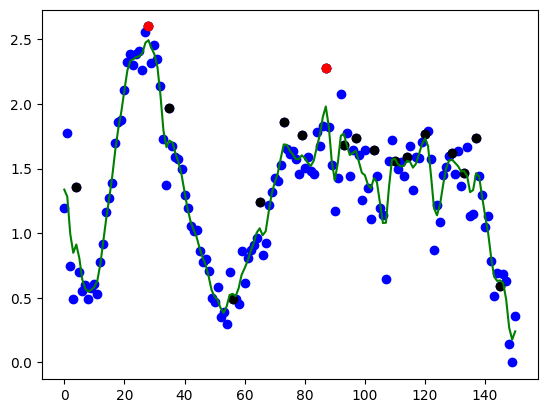

In [23]:
condition = 2
neuron = 3
xval_true = 1
test = tuning[condition][xval[:,condition] == xval_true,:]
firing_rates  = test[neuron,:]
firing_rates = firing_rates + abs(np.amin(firing_rates))+ 1e-6 # Add a small epsilon to avoid exact zero
distances = np.arange(len(firing_rates))

def moving_average(data, window_size):
    return np.convolve(data, np.ones(window_size) / window_size, mode='same')

# Example smoothing
window_size = 10  # Choose an appropriate window size
smoothed_firing_rates = moving_average(firing_rates, window_size)

from scipy.ndimage import gaussian_filter1d

# Example smoothing
sigma = 1.0  # Standard deviation of the Gaussian kernel
smoothed_firing_rates = gaussian_filter1d(firing_rates, sigma)

# from scipy.signal import savgol_filter

# # Example smoothing
# window_length = 5  # Must be odd
# poly_order = 2  # Degree of the polynomial
# smoothed_firing_rates = savgol_filter(firing_rates, window_length, poly_order)

# Find peaks in firing rates
peak_indices, _ = find_peaks(smoothed_firing_rates, height=0)  # Only positive peaks
prominent_peaks = sorted(peak_indices, key=lambda i: firing_rates[i], reverse=True)[:2]

plt.scatter(distances, firing_rates, label="Original Data", color="blue")
plt.scatter(distances[peak_indices], firing_rates[peak_indices], color="black", label="Peaks")
plt.scatter(distances[prominent_peaks], firing_rates[prominent_peaks], color="red", label="Peaks")
plt.plot(distances, smoothed_firing_rates, label="Smoothed Data", color="green")
plt.show()

In [ ]:
# TODO: take the most prominent peak and then remove all peaks wihtin single gaussian sigma of it, then take the next biggest peak

In [ ]:
from behave_analysis.utils.creating_directories import make_directory
nickname = exp.nick_name + '_' + exp.experiment_date + '_' + comp
dump_path = make_directory("Z:/Jasmine_Laurence/summary_plots/tuning_curves/"+nickname)

for condition in [0,1,2]:
    xval_true = 1
    test = tuning[condition][xval[:,condition] == xval_true,:]
    for neuron in np.arange(test.shape[0]):
        flatline = np.where(np.diff((np.mean(test, axis = 0) == 0).astype(int)) == 1)[0]
        if len(flatline) > 0:
            test = test[:,:flatline[0]]
        firing_rates  = test[neuron,:]
        firing_rates = firing_rates + abs(np.amin(firing_rates))+ 1e-6 # Add a small epsilon to avoid exact zero
        distances = np.arange(len(firing_rates))

        # single gaussian
        try:
            y_fitted, R, params = fit_gaussian(firing_rates, distances)
        except:
            y_fitted = np.zeros_like(firing_rates)
            R = 0

        # from scipy.ndimage import gaussian_filter1d
        sigma = 1.0  # Standard deviation of the Gaussian kernel
        smoothed_firing_rates = gaussian_filter1d(firing_rates, sigma)

        # Find peaks in firing rates
        peak_indices, _ = find_peaks(smoothed_firing_rates, height=0)  # Only positive peaks
        if len(peak_indices) < 2:
            print("Warning: Less than 2 peaks detected. Double Gaussian may not be appropriate.")
            y_fitted_double = np.zeros_like(y_fitted)
            R_double = 0
        # Sort peaks by prominence
        elif len(peak_indices) >= 2:
            # TODO: take the most prominent peak and then remove all peaks wihtin single gaussian sigma of it, then take the next biggest peak
            prominent_peaks = sorted(peak_indices, key=lambda i: firing_rates[i], reverse=True)[:2]
            initial_guess_double = [
                                    firing_rates[prominent_peaks[0]],  # A1
                                    prominent_peaks[0],  # mu1 (left peak)
                                    np.std(distances),  # sigma1
                                    firing_rates[prominent_peaks[1]],  # A1
                                    prominent_peaks[1],  # mu2 (right peak)
                                    np.std(distances)   # sigma2
                                ]
            try:
                y_fitted_double, R_double, params_double = fit_double_gaussian(firing_rates, distances, initial_guess_double)
            except:
                y_fitted_double = np.zeros_like(firing_rates)
                R_double = 0

        # Plot original data and fitted Gaussian
        fig, axs = plt.subplots(1,2,figsize = (12,4))
        axs[0].scatter(distances, firing_rates, label="Original Data", color="blue")
        axs[0].plot(distances, y_fitted, label="Fitted Gaussian", color="red")
        axs[0].plot(distances, y_fitted_double, label="Fitted Gaussian", color="green")
        axs[0].scatter(distances[prominent_peaks], firing_rates[prominent_peaks], color="red", label="Peaks")
        axs[0].set_ylabel("Firing Rate")
        axs[0].set_xlabel(comp)
        axs[0].legend()
        axs[0].set_title("Gaussian Fit\n R^2 = " + str(R) + "\n Double Gaussian R^2 = " + str(R_double))

        xval_mat = mat_by_cond[condition][xval[:,condition] == xval_true,:,:]
        axs[1].imshow(xval_mat[neuron,:], cmap="gray_r", vmin = 0, vmax = 1.2, aspect="auto", interpolation = "none")
        axs[1].set_ylabel("Trials")

        c = ['shelter_only', 'barrier', 'barrier_flipped']
        if xval_true:
            fig.savefig(dump_path + "/xval_neuron" + str(neuron) + '_' + c[condition] + ".png")
        else:
            fig.savefig(dump_path + "/neuron" + str(neuron) + '_' + c[condition] + ".png")
        plt.close()

Fitted parameters: A = 2.08, mu = 45.25, sigma = 19.96
Fitted parameters (Double Gaussian): A1 = 2.08, mu1 = 45.25, sigma1 = 19.96, A2 = -37.76, mu2 = 468.85, sigma2 = 4.28
Fitted parameters: A = 1.97, mu = 53.44, sigma = 42.57
Fitted parameters (Double Gaussian): A1 = -9.52, mu1 = 875.96, sigma1 = -10.54, A2 = -13.32, mu2 = -794.14, sigma2 = 82.42
Fitted parameters (Double Gaussian): A1 = -20.42, mu1 = 3967.24, sigma1 = 344.79, A2 = -21.24, mu2 = -10856.21, sigma2 = 1184.39
Fitted parameters (Double Gaussian): A1 = 223.04, mu1 = -1048.65, sigma1 = 104.17, A2 = -224.20, mu2 = -1438.20, sigma2 = -46.48
Fitted parameters: A = 0.13, mu = -0.49, sigma = 0.31
Fitted parameters: A = 1.84, mu = 61.09, sigma = 16.20
Fitted parameters (Double Gaussian): A1 = -40.36, mu1 = -539.05, sigma1 = 66.91, A2 = 1.84, mu2 = 61.09, sigma2 = 16.20
Fitted parameters: A = 2.03, mu = 81.96, sigma = 50.32
Fitted parameters (Double Gaussian): A1 = -518.49, mu1 = -3144.75, sigma1 = 137.18, A2 = 2.03, mu2 = 81.96,

In [ ]:
condition = 2
neuron = 3
xval_true = 1
test = tuning[condition][xval[:,condition] == xval_true,:]
firing_rates  = test[neuron,:]
firing_rates = firing_rates + abs(np.amin(firing_rates))+ 1e-6 # Add a small epsilon to avoid exact zero
distances = np.arange(len(firing_rates))
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

def gaussian(x, A, mu, sigma):
    return A * np.exp(-((x - mu) ** 2) / (2 * sigma ** 2))

# Define double Gaussian function
def double_gaussian(x, A1, mu1, sigma1, A2, mu2, sigma2):
    gaussian1 = A1 * np.exp(-((x - mu1) ** 2) / (2 * sigma1 ** 2))
    gaussian2 = A2 * np.exp(-((x - mu2) ** 2) / (2 * sigma2 ** 2))
    return gaussian1 + gaussian2

# Fit Gaussian to the data
initial_guess = [max(firing_rates), distances[np.argmax(firing_rates)], np.std(distances)]  # Initial guesses for A, mu, sigma
params, covariance = curve_fit(gaussian, distances, firing_rates, p0=initial_guess)

# Extract parameters
A, mu, sigma = params
print(f"Fitted parameters: A = {A:.2f}, mu = {mu:.2f}, sigma = {sigma:.2f}")

# Generate points for the fitted Gaussian
# x_fitted = np.linspace(min(distances), max(distances), 100)
x_fitted = distances
y_fitted = gaussian(x_fitted, A, mu, sigma)
R = compute_r_squared(firing_rates, y_fitted)

# Fit the double Gaussian model
# Initial guesses for the parameters (two peaks)
half = int(len(firing_rates) // 2)
initial_guess_double = [
    max(firing_rates[:half]),  # A1
    distances[np.argmax(firing_rates[:half])],  # mu1 (left peak)
    np.std(distances),  # sigma1
    max(firing_rates[half:]),  # A2
    distances[np.argmax(firing_rates[half:])],  # mu2 (right peak)
    np.std(distances)   # sigma2
]
try:
    params_double, covariance_double = curve_fit(double_gaussian, distances, firing_rates, p0=initial_guess_double)

    # Extract fitted parameters
    A1, mu1, sigma1, A2, mu2, sigma2 = params_double
    print(f"Fitted parameters (Double Gaussian): A1 = {A1:.2f}, mu1 = {mu1:.2f}, sigma1 = {sigma1:.2f}, A2 = {A2:.2f}, mu2 = {mu2:.2f}, sigma2 = {sigma2:.2f}")

    # Generate points for the fitted Gaussian
    # x_fitted = np.linspace(min(distances), max(distances), 100)
    y_fitted_double = double_gaussian(x_fitted, A1, mu1, sigma1, A2, mu2, sigma2)
    R_double = compute_r_squared(firing_rates, y_fitted_double)
except:
    print("Couldn't fit double gaussian")
    y_fitted_double = np.zeros_like(y_fitted)
    R_double = 0

# Plot original data and fitted Gaussian
fig, axs = plt.subplots(1,2,figsize = (12,4))
axs[0].scatter(distances, firing_rates, label="Original Data", color="blue")
axs[0].plot(x_fitted, y_fitted, label="Fitted Gaussian", color="red")
axs[0].plot(x_fitted, y_fitted_double, label="Fitted Gaussian", color="green")
axs[0].set_xlabel("Distance")
axs[0].set_ylabel("Firing Rate")
axs[0].legend()
axs[0].set_title("Gaussian Fit\n R^2 = " + str(R) + "\n Double Gaussian R^2 = " + str(R_double))

xval_mat = mat_by_cond[condition][xval[:,condition] == xval_true,:,:]
axs[1].imshow(xval_mat[neuron,:], cmap="gray_r", vmin = 0, vmax = 1.2, aspect="auto", interpolation = "none")
axs[1].set_ylabel("Trials")